In [118]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmap

run = pd.Timestamp("2022-11-17-00", tz="utc").replace(tzinfo=None).floor('24h')
run

H = Herbie(run, model="gfs", product="pgrb2.0p25", fxx=6, save_dir='./data/', overwrite=True)
ss = r"((HGT|UGRDd|VGRD|RH|O3MR):(2 m above ground|1000|850|700|500|250)|:PRMSL:mean sea level:6 hour fcst|APCP|:HPBL: surface :6 hour fcst|TMP:surface)"
H.inventory(ss)
fp = H.download(ss)
ds = xr.open_dataset(fp, engine = 'cfgrib')
ds

H.inventory(ss)

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2022-Nov-17 00:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,996621.0,0-996621,2022-11-17,2022-11-17 06:00:00,PRMSL,mean sea level,6 hour fcst,:PRMSL:mean sea level:6 hour fcst
268,269,210385045,211130898.0,210385045-211130898,2022-11-17,2022-11-17 06:00:00,HGT,250 mb,6 hour fcst,:HGT:250 mb:6 hour fcst
270,271,211886865,212715500.0,211886865-212715500,2022-11-17,2022-11-17 06:00:00,RH,250 mb,6 hour fcst,:RH:250 mb:6 hour fcst
276,277,217139249,217741725.0,217139249-217741725,2022-11-17,2022-11-17 06:00:00,VGRD,250 mb,6 hour fcst,:VGRD:250 mb:6 hour fcst
283,284,220086641,221345955.0,220086641-221345955,2022-11-17,2022-11-17 06:00:00,O3MR,250 mb,6 hour fcst,:O3MR:250 mb:6 hour fcst
348,349,264420853,265239821.0,264420853-265239821,2022-11-17,2022-11-17 06:00:00,HGT,500 mb,6 hour fcst,:HGT:500 mb:6 hour fcst
350,351,265969689,266789532.0,265969689-266789532,2022-11-17,2022-11-17 06:00:00,RH,500 mb,6 hour fcst,:RH:500 mb:6 hour fcst
356,357,271404343,271960946.0,271404343-271960946,2022-11-17,2022-11-17 06:00:00,VGRD,500 mb,6 hour fcst,:VGRD:500 mb:6 hour fcst
363,364,273729962,274800337.0,273729962-274800337,2022-11-17,2022-11-17 06:00:00,O3MR,500 mb,6 hour fcst,:O3MR:500 mb:6 hour fcst
412,413,307400938,308259093.0,307400938-308259093,2022-11-17,2022-11-17 06:00:00,HGT,700 mb,6 hour fcst,:HGT:700 mb:6 hour fcst


In [60]:
subset = ds.sel(longitude=slice(-130, -65), latitude=slice(55, 20)) 
subset = ds.sel(longitude=slice(230, 295), latitude=slice(55, 20))

fig, ax = EasyMap("50m", crs=ds.herbie.crs, figsize=[8, 8]).STATES().ax
p = ax.pcolormesh(
    subset.longitude, 
    subset.latitude, 
    subset.t2m-273.15,
    transform=pc,
    **paint.NWSTemperature.kwargs2,
)

plt.colorbar(p, ax=ax, orientation="horizontal", pad=0.05, **paint.NWSTemperature.cbar_kwargs2)

ax.set_title(ds.t2m.GRIB_name, loc="right")
ax.set_title(f"{ds.model.upper()}: {H.product_description}", loc="left")

NameError: name 'EasyMap' is not defined

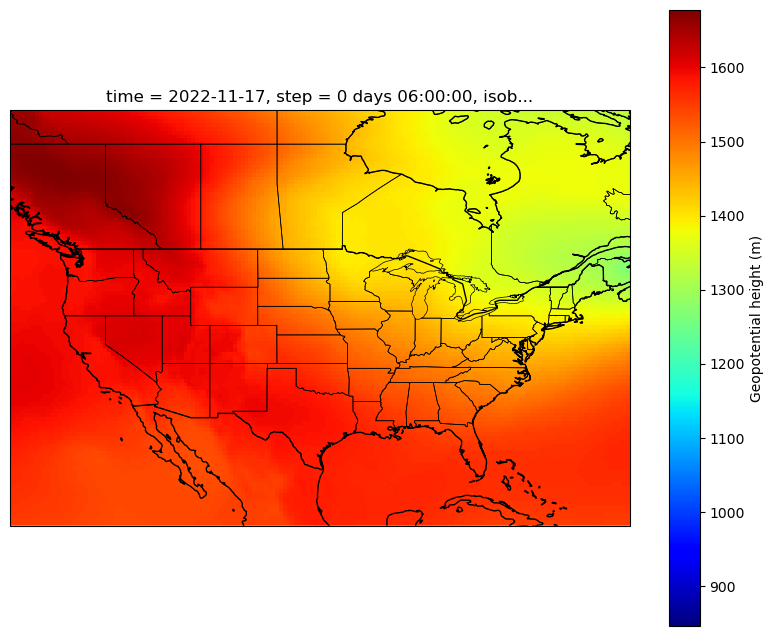

In [102]:
def basemap():
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-130,-65, 20, 60])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    return fig, ax
    
ds_loc = ds.sel(latitude=slice(55,20),longitude=slice(-130,-60))
fig, ax = basemap()

temp_f = (ds['gh'].sel(isobaricInhPa=850))

temp_f.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet',
    cbar_kwargs={'label': 'Geopotential height (m)'}
)

In [142]:
gh500 = ds['gh'].sel(isobaricInhPa=850)
u500 = ds['u'].sel(isobaricInhPa=850)
v500 = ds['v'].sel(isobaricInhPa=850)

ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
ds = ds.sortby('longitude')
ds = ds.sortby('latitude')

fig, ax = basemap()

ax.streamplot(ds.longitude.values, ds.latitude.values, u500.values, v500.values, transform=ccrs.PlateCarree(), density=1, linewidth = 0.5, color="red")
ax.set_title(f"GFS Ensemble Mean Wind 700hPa\n" f"Valid:")

plt.show()

KeyError: "No variable named 'u'. Variables on the dataset include ['time', 'step', 'meanSea', 'latitude', 'longitude', ..., 't', 'heightAboveGround', 'r2', 'tp', 'sit']"

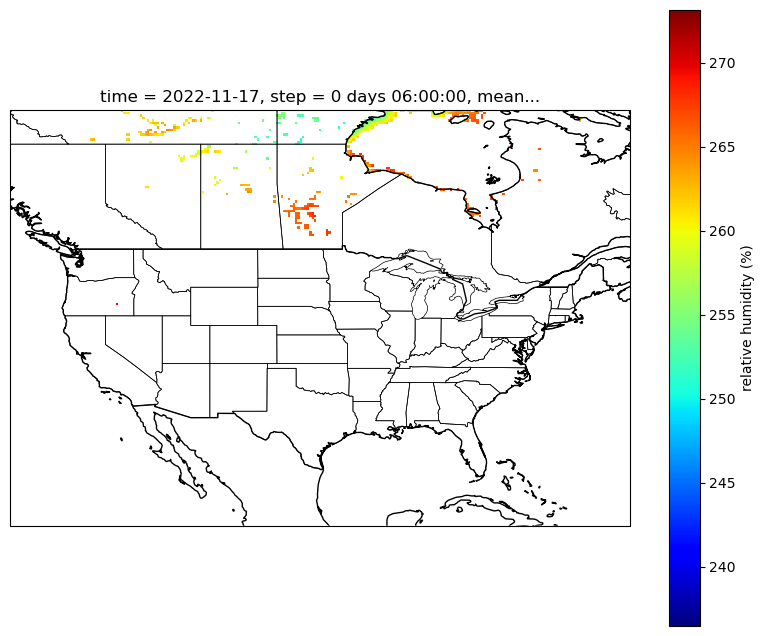

In [121]:
ds_loc = ds.sel(latitude=slice(55,20),longitude=slice(-130,-60))
fig, ax = basemap()

temp_f = (ds['sit'])

temp_f.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap = 'jet',
    cbar_kwargs={'label': 'relative humidity (%)'}
)

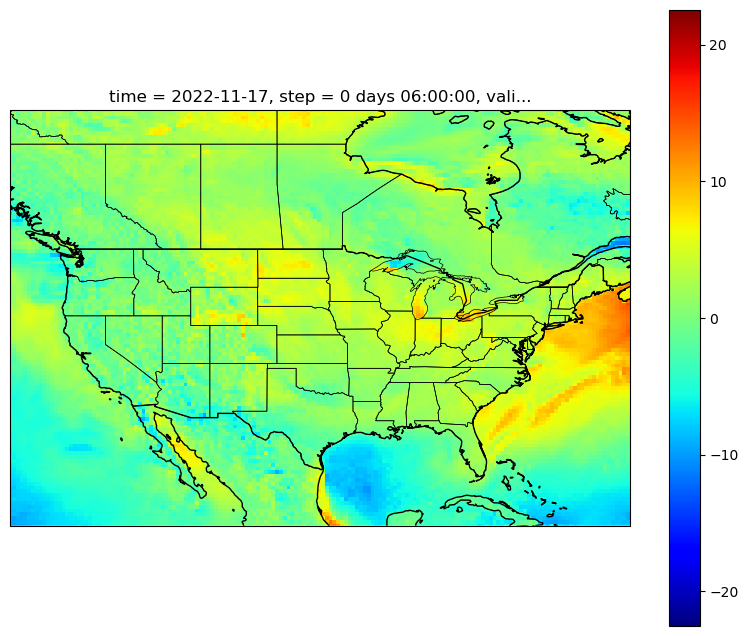

In [111]:
ds_loc = ds.sel(latitude=slice(55,20),longitude=slice(-130,-60))
fig, ax = basemap()

temp_f = (ds['u10'])

temp_f.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap = 'jet',
    cbar_kwargs={'label': ''}
)

TypeError: cannot directly convert an xarray.Dataset into a numpy array. Instead, create an xarray.DataArray first, either with indexing on the Dataset or by invoking the `to_dataarray()` method.

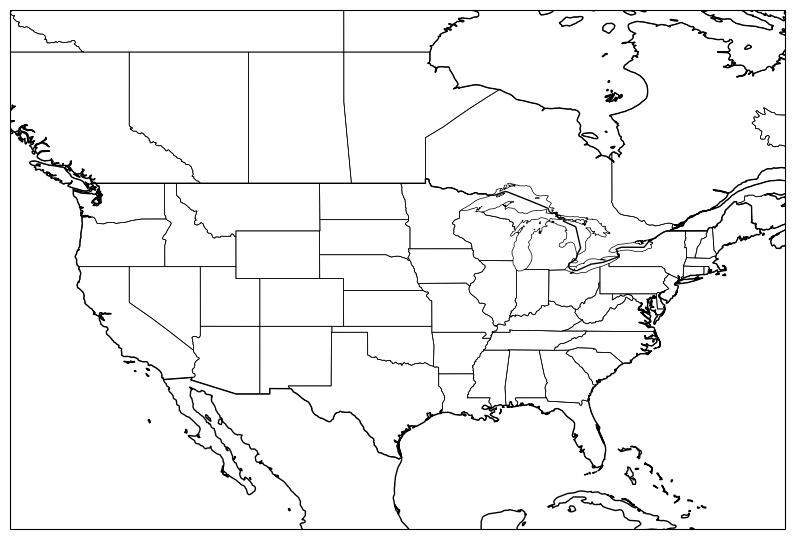

In [17]:
u_1000 = ds['u'].sel(isobaricInhPa=1000)
v_1000 = ds['v'].sel(isobaricInhPa=1000)
dataproj = ccrs.PlateCarree()

ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
ds = ds.sortby('longitude')
ds = ds.sortby('latitude')

ds_loc = ds.sel(latitude=slice(55,20),longitude=slice(-130,-60))
fig, ax = basemap()

ax.streamplot(ds_loc, ds_loc, u_1000.values, v_1000.values, transform=dataproj, color='black', linewidth=0.8, density=1.5)



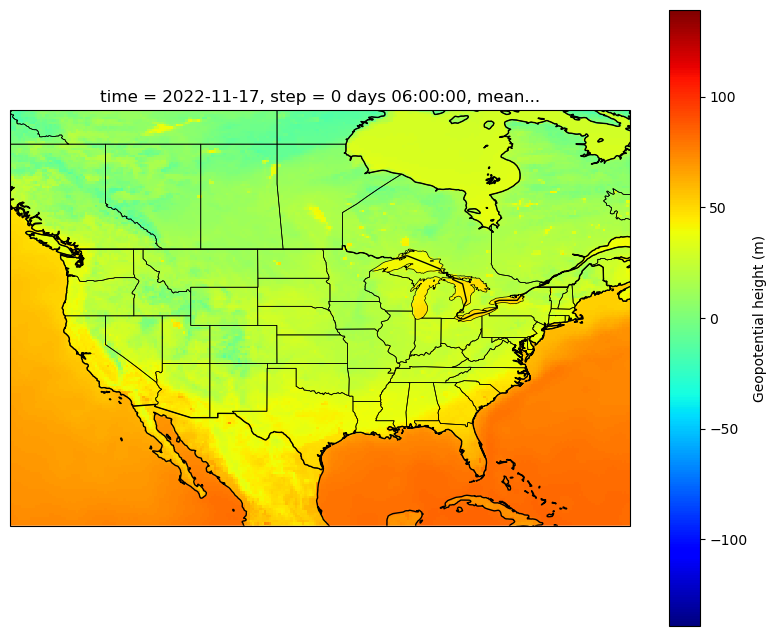

In [137]:
ds_loc = ds.sel(latitude=slice(55,20),longitude=slice(-130,-60))
fig, ax = basemap()

temp_f = ((ds['t']) - 273.15) * 9/5 + 32

temp_f.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap = 'jet',
    cbar_kwargs={'label': 'Geopotential height (m)'}
)

KeyError: "No variable named 't2m'. Variables on the dataset include ['time', 'step', 'meanSea', 'latitude', 'longitude', ..., 't', 'heightAboveGround', 'r2', 'tp', 'sit']"

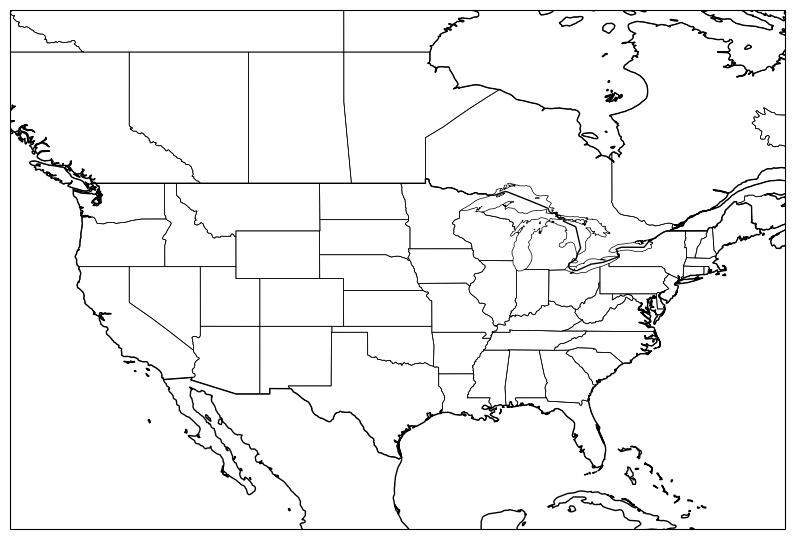

In [133]:
fig, ax = basemap()
CBAR_KWARGS = {'orientation': 'horizontal', 'pad': 0.08, 'aspect': 50, 'shrink': 0.7}

cf = ax.contourf(ds.longitude, ds.latitude, ds['t2m'], levels=np.arange(0, 9, 1), cmap='jet', extend='max')
cb = plt.colorbar(cf, **CBAR_KWARGS)
cb.set_label('Precipitation (inches)')



In [49]:
ds

<xarray.Dataset> Size: 129MB
Dimensions:            (latitude: 721, longitude: 1440, isobaricInhPa: 5)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    meanSea            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    prmsl              (latitude, longitude) float32 4MB ...
    vis                (latitude, longitude) float32 4MB ...
    gh                 (isobaricInhPa, latitude, longitude) float32 21MB ...
    t                  (isobaricInhPa, latitude, longitude) float32 21MB ...
    r                  (isobaricInhPa, latitude, longitude) float32 21MB ...
    u                  (isobaricInhPa, latitude, longitude) float32 21MB ...
    v                  (isobaricInhPa, latitude, longitude) float32 21MB ...
    t2m                (latitude, longitude) float32 4MB ...
    r2                 (latitude, longitude) float32 4MB ...
    aptmp              (latitude, longitude) float32 4MB ...
    tp                 (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T15:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [120]:
ds

<xarray.Dataset> Size: 104MB
Dimensions:            (latitude: 721, longitude: 1440, isobaricInhPa: 5)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    meanSea            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    prmsl              (latitude, longitude) float32 4MB ...
    gh                 (isobaricInhPa, latitude, longitude) float32 21MB ...
    r                  (isobaricInhPa, latitude, longitude) float32 21MB ...
    v                  (isobaricInhPa, latitude, longitude) float32 21MB ...
    o3mr               (isobaricInhPa, latitude, longitude) float32 21MB ...
    t                  (latitude, longitude) float32 4MB ...
    r2                 (latitude, longitude) float32 4MB ...
    tp                 (latitude, longitude) float32 4MB ...
    sit                (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T17:11 GRIB to CDM+CF via cfgrib-0.9.1...